In [1]:
import os
import sys
from pathlib import Path
import yaml

# --- Find project root ---
project_root = Path.cwd()
while not (project_root / "configs").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

print("Project root:", project_root)

# --- Load user config (NO HARDCODING) ---
PROJECT_USER_CONFIG = os.environ.get("PROJECT_USER_CONFIG")

if PROJECT_USER_CONFIG is None:
    raise ValueError("PROJECT_USER_CONFIG environment variable is not set")

config_path = project_root / PROJECT_USER_CONFIG

print("Loading config from:", config_path)

with open(config_path, "r") as f:
    user_config = yaml.safe_load(f)

# --- Resolve paths ---
bucket = user_config["aws"]["project_bucket"]
gold_prefix = user_config["aws"]["gold_prefix"]

gold_root = f"s3a://{bucket}/{gold_prefix}"

print("Gold root:", gold_root)

Project root: /home/ubuntu/renewable-energy-forecasting-pipeline
Loading config from: /home/ubuntu/renewable-energy-forecasting-pipeline/configs/users/syed.yaml
Gold root: s3a://syed-datsbd-s2026/gold/wind


In [2]:
from src.common.spark_utils import get_spark_session

spark = get_spark_session(
    app_name="presentation_eda",
    master="local[*]"
)

spark.sparkContext.setLogLevel("WARN")
print(spark.sparkContext.master)

region_daily = spark.read.parquet(f"{gold_root}/analytics/daily_region")
region_monthly = spark.read.parquet(f"{gold_root}/analytics/monthly_state")

print("Loaded data successfully")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-cdb9d222-5f3d-40d7-a9a1-e7e8ccfac4ae;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 439ms :: artifacts dl 28ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	--------------------------------

local[*]


26/04/28 10:05:30 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Loaded data successfully


In [3]:
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel

region_daily = region_daily.persist(StorageLevel.MEMORY_AND_DISK)
region_monthly = region_monthly.persist(StorageLevel.MEMORY_AND_DISK)

print("daily rows:", region_daily.count())
print("monthly rows:", region_monthly.count())

daily rows: 537449


monthly rows: 17664


## Q1: How does wind potential vary over time?

### What is being measured?

The Y-axis shows **average capacity factor**.

Capacity factor represents:
- the fraction of maximum possible energy output from wind
- ranges between **0 and 1**

Interpretation:
- 0 → no usable wind energy
- 1 → turbine operating at full capacity (rare)
- 0.06 → ~6% of maximum possible output on average

This is NOT raw wind speed —  
it is a **physics-based transformation of wind into energy potential** using a turbine power curve.

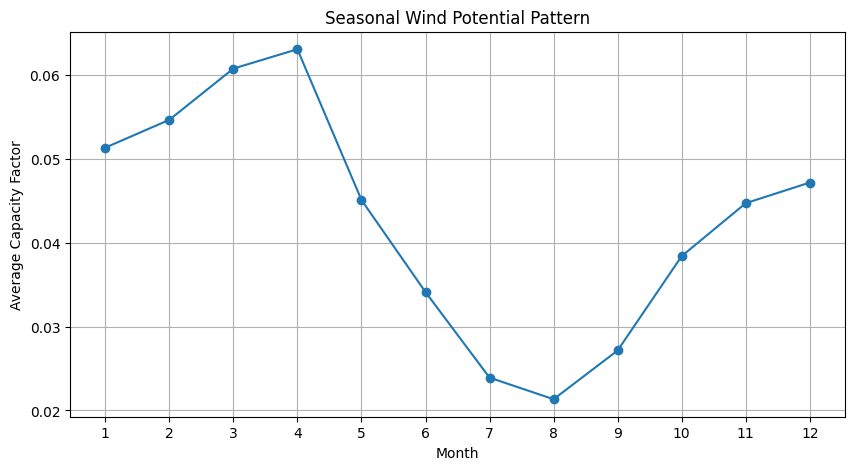

In [4]:
import matplotlib.pyplot as plt

seasonal = (
    region_monthly
    .groupBy("month")
    .agg(F.avg("monthly_region_capacity_factor").alias("avg_cf"))
    .orderBy("month")
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.plot(seasonal["month"], seasonal["avg_cf"], marker="o")
plt.title("Seasonal Wind Potential Pattern")
plt.xlabel("Month")
plt.ylabel("Average Capacity Factor")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## Q2: Where is wind potential strongest?

### What is being measured?

The Y-axis again shows **average capacity factor**.

This represents:
- long-run average energy output potential from wind
- aggregated across all days from 1995–2025

Example:
- 0.09 → very strong wind region (~9% average output)
- 0.01 → very weak wind region (~1% average output)

This is a **long-term energy potential metric**, not a single-day value.

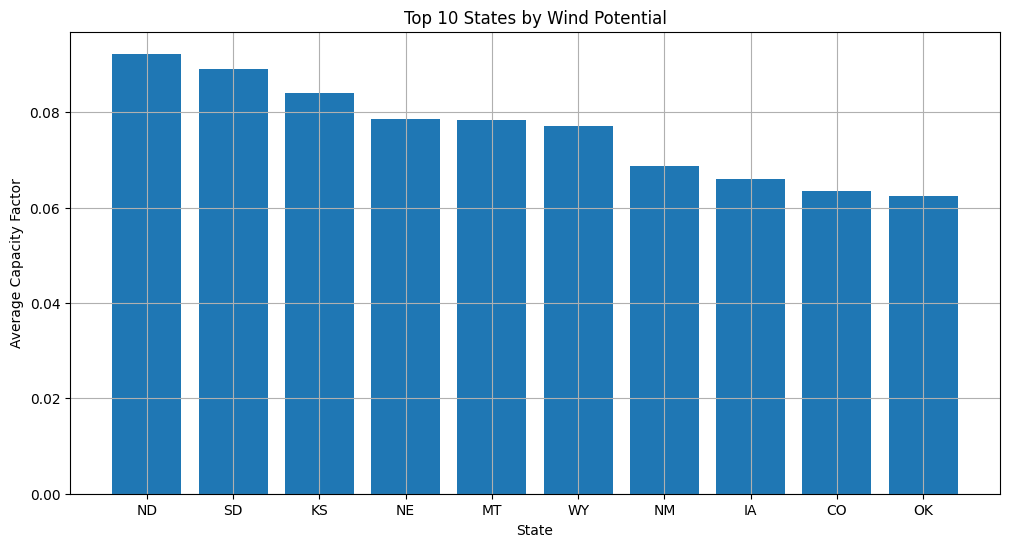

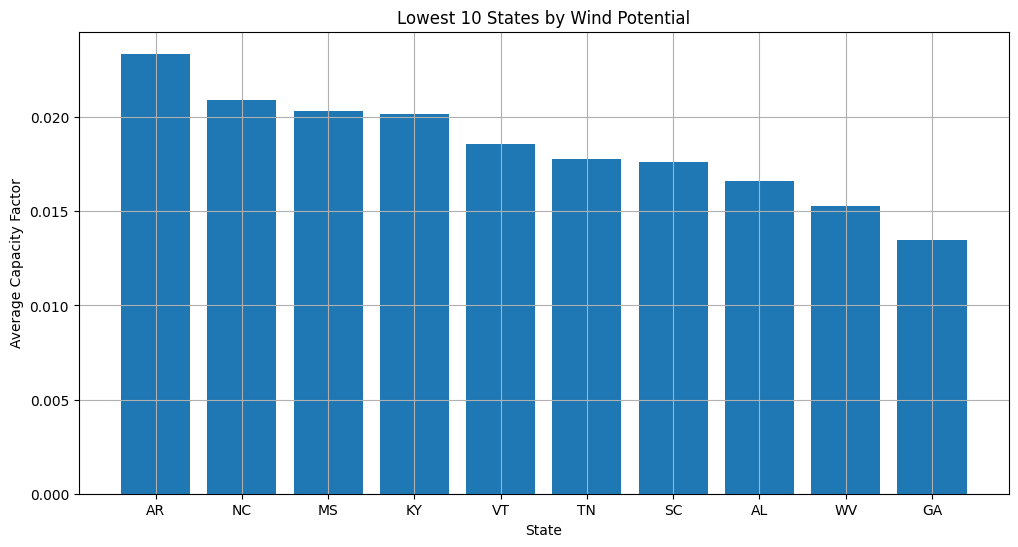

In [6]:
import matplotlib.pyplot as plt

state_rankings = (
    region_monthly
    .groupBy("state")
    .agg(
        F.avg("monthly_region_capacity_factor").alias("avg_cf")
    )
    .orderBy(F.desc("avg_cf"))
    .toPandas()
)

# Top 10 states
top_states = state_rankings.head(10)

# Bottom 10 states
bottom_states = state_rankings.tail(10)

plt.figure(figsize=(12,6))

# Plot top states
plt.bar(top_states["state"], top_states["avg_cf"])

plt.title("Top 10 States by Wind Potential")
plt.xlabel("State")
plt.ylabel("Average Capacity Factor")
plt.grid(True)

plt.show()


plt.figure(figsize=(12,6))

# Plot bottom states
plt.bar(bottom_states["state"], bottom_states["avg_cf"])

plt.title("Lowest 10 States by Wind Potential")
plt.xlabel("State")
plt.ylabel("Average Capacity Factor")
plt.grid(True)

plt.show()

### Analysis

Wind potential is highly uneven across the United States.

The top-performing states — North Dakota, South Dakota, Kansas, and Nebraska — show the highest average capacity factors, all above ~0.075.

0.075 means that on average, the wind is producing about 7.5% of the maximum possible energy output a turbine could generate under ideal conditions.

In contrast, the lowest-performing states — Georgia, West Virginia, Alabama, and others — have values below ~0.02.

This represents a **massive difference in energy potential**:
- North Dakota (~0.092) produces nearly **7 times more wind energy potential** than Georgia (~0.013)

The top states are geographically clustered in the **Great Plains and central U.S.**, while the lowest states are concentrated in the **Southeast and Appalachian regions**.

This pattern is not coincidental — it reflects physical geography:
- Great Plains:
  - flat terrain
  - low surface friction
  - strong, consistent wind flows
- Southeast:
  - higher vegetation and terrain complexity
  - weaker large-scale wind systems

### Insight

Wind energy potential is **dominated by geography**, not randomness.

### Real-world meaning

- Wind farms are economically viable primarily in central U.S. regions
- Some states are fundamentally unsuitable for large-scale wind energy
- Location selection is the most critical decision in wind energy deployment

# Q3: How does wind potential vary over long-term trends?

This question examines whether wind potential is stable over multiple decades or whether it changes substantially over time.

The goal is to compare selected high-, medium-, and low-potential states across 1995–2025.

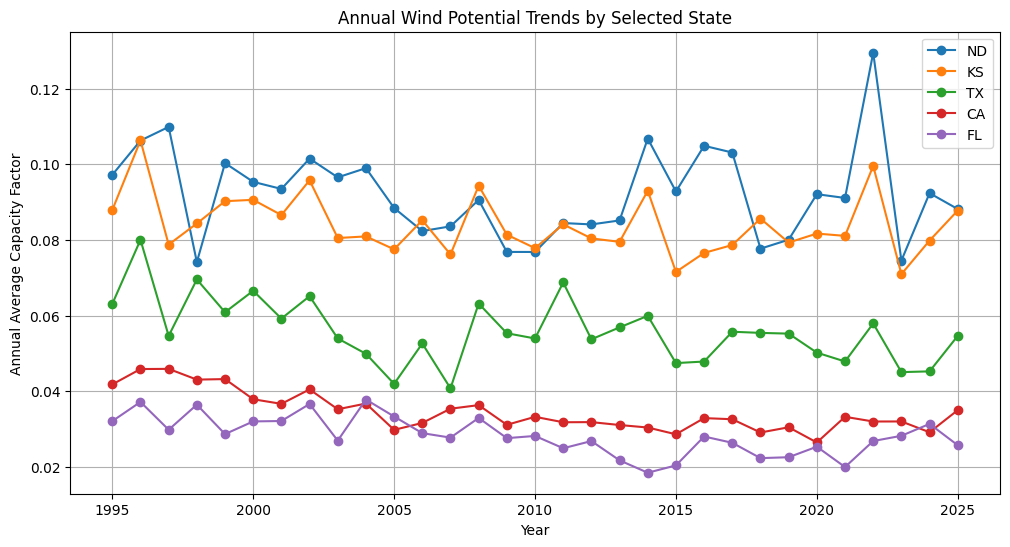

In [7]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

selected_states = ["ND", "KS", "TX", "CA", "FL"]

annual_trends = (
    region_monthly
    .where(F.col("state").isin(selected_states))
    .groupBy("state", "year")
    .agg(
        F.avg("monthly_region_capacity_factor").alias("annual_avg_capacity_factor")
    )
    .orderBy("state", "year")
    .toPandas()
)

plt.figure(figsize=(12, 6))

for state in selected_states:
    subset = annual_trends[annual_trends["state"] == state]
    plt.plot(
        subset["year"],
        subset["annual_avg_capacity_factor"],
        marker="o",
        label=state,
    )

plt.title("Annual Wind Potential Trends by Selected State")
plt.xlabel("Year")
plt.ylabel("Annual Average Capacity Factor")
plt.legend()
plt.grid(True)
plt.show()

### Analysis

This plot shows the **long-term evolution of wind potential (capacity factor)** across five representative states:
- High wind: ND, KS  
- Medium wind: TX  
- Low wind: CA, FL  

### Key observations

1. **Strong geographic separation is persistent**
   - North Dakota (ND) and Kansas (KS) consistently remain the highest
   - Texas (TX) stays in the middle
   - California (CA) and Florida (FL) remain the lowest

   → The ranking **does not change over time**


2. **No clear long-term upward or downward trend**
   - None of the states show a steady increase or decrease from 1995–2025
   - Instead, values fluctuate around a stable mean

   → Wind potential is **stationary over decades**

3. **Year-to-year variability exists but is bounded**
   - ND fluctuates roughly between ~0.075 and ~0.13  
   - KS fluctuates around ~0.07–0.10  
   - Low-wind states fluctuate within much smaller ranges (~0.02–0.04)

   → Variability exists, but it is **not chaotic**

4. **Occasional spikes (extreme years)**
   - Example: ND shows a large spike around 2022 (~0.13)
   - These are rare but noticeable

   → These represent **extreme wind years**, not structural change

### Insight

Wind potential is:

- **Geographically determined (dominant factor)**
- **Stable over long time horizons**
- **Variable in the short term, but within predictable bounds**

### Real-world meaning

- Wind energy is a **reliable long-term resource**
- Site selection matters more than time-based changes
- Forecasting is feasible because:
  - no structural drift
  - variability is bounded
- Energy planners can treat wind potential as **stable infrastructure input**, not a changing resource

# Q4: How stable is wind potential?

This question evaluates the **distribution and variability** of wind potential.

Instead of looking at averages, we analyze:
- how values are spread
- how often extreme values occur
- whether wind is predictable or highly volatile

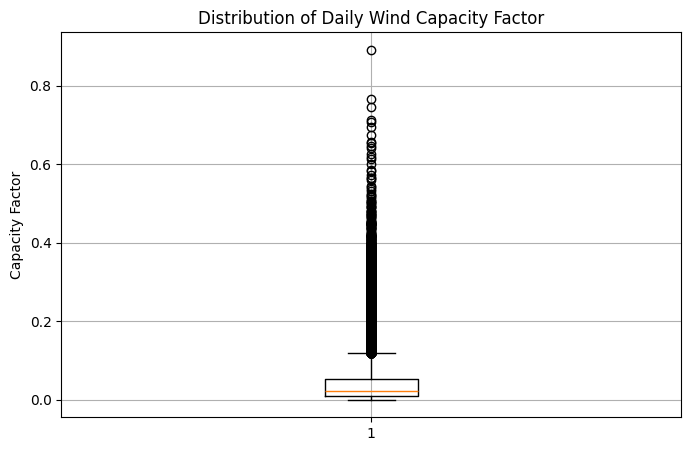

In [9]:
import matplotlib.pyplot as plt

daily_sample = (
    region_daily
    .select("daily_region_capacity_factor")
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.boxplot(daily_sample["daily_region_capacity_factor"], vert=True)
plt.title("Distribution of Daily Wind Capacity Factor")
plt.ylabel("Capacity Factor")
plt.grid(True)
plt.show()

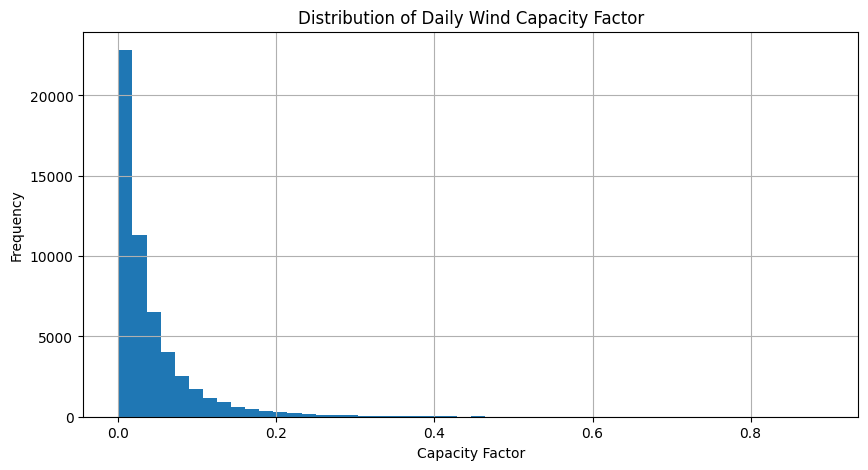

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(daily_sample["daily_region_capacity_factor"], bins=50)
plt.title("Distribution of Daily Wind Capacity Factor")
plt.xlabel("Capacity Factor")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Analysis

These plots show the **distribution of daily wind capacity factor**, which tells us how stable and predictable wind energy is.

### Key observations

1. **Most values are very low**
   - The histogram shows a heavy concentration near **0–0.05**
   - The median (from earlier stats) is around ~0.02–0.03

   → Most days have **low-to-moderate wind energy output**

2. **Strong right-skewed distribution**
   - The distribution has a long tail extending toward higher values
   - High wind days (0.2, 0.3, and above) are **rare but present**

   → Wind is **not symmetric** — strong wind events are uncommon

3. **Limited variability for most observations**
   - The box plot shows a **tight central box**
   - Most data lies in a narrow range

   → Day-to-day variation is **bounded and controlled**

4. **Presence of extreme outliers**
   - The box plot shows many points above the upper whisker
   - Some values go as high as ~0.9

   → These are **extreme wind events**, not typical behavior

### Insight

Wind potential is:

- **Mostly stable and low-to-moderate**
- **Occasionally spikes to very high values**
- **Highly skewed rather than normally distributed**

### Real-world meaning

- Wind energy is **reliable but not constant**
- Most days produce moderate output
- Grid systems must handle:
  - **frequent low-output periods**
  - **occasional high-output surges**

- This explains why:
  - storage systems are important
  - forecasting extreme events is valuable

# Q4B: Which regions have more stable wind patterns?

This analysis compares wind stability across states.

We evaluate stability using:

- **Volatility (standard deviation)** → how much wind fluctuates daily  
- **Coefficient of Variation (CV)** → volatility relative to average wind  

This helps answer:

- Are high-wind states more stable?
- Which regions are predictable vs volatile?

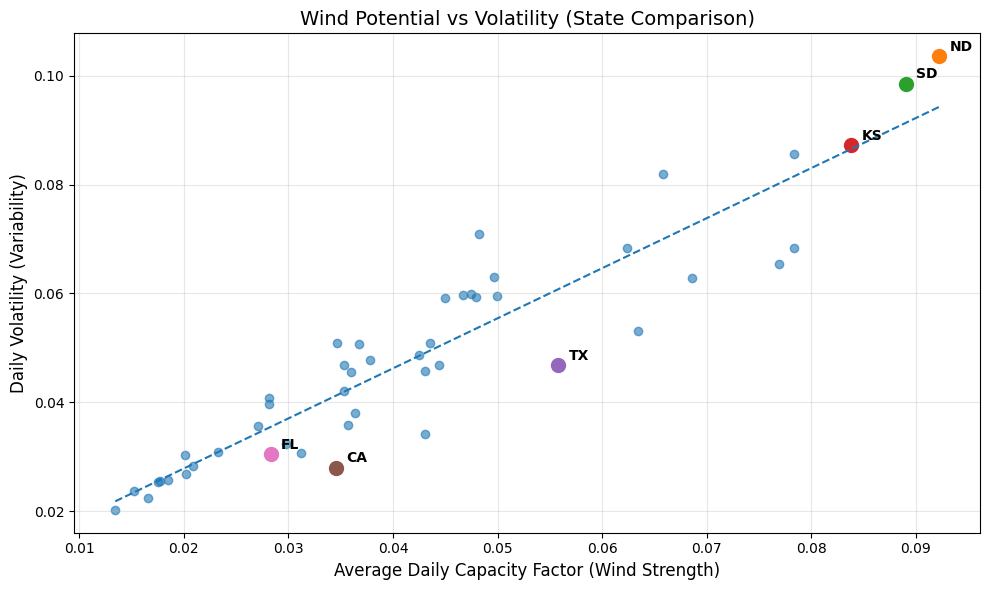

In [21]:
import matplotlib.pyplot as plt
import numpy as np

stability = (
    region_daily
    .groupBy("state")
    .agg(
        F.avg("daily_region_capacity_factor").alias("avg_daily_cf"),
        F.stddev("daily_region_capacity_factor").alias("daily_volatility"),
    )
    .withColumn(
        "coefficient_of_variation",
        F.col("daily_volatility") / F.col("avg_daily_cf")
    )
    .orderBy(F.desc("avg_daily_cf"))
)

# Convert to pandas
stability_pd = stability.toPandas()

# Create figure
plt.figure(figsize=(10, 6))

# Scatter
plt.scatter(
    stability_pd["avg_daily_cf"],
    stability_pd["daily_volatility"],
    alpha=0.6
)

# Highlight key states
highlight_states = ["ND", "SD", "KS", "TX", "CA", "FL"]

for _, row in stability_pd.iterrows():
    if row["state"] in highlight_states:
        plt.scatter(
            row["avg_daily_cf"],
            row["daily_volatility"],
            s=100  # bigger dot
        )
        plt.text(
            row["avg_daily_cf"] + 0.001,
            row["daily_volatility"] + 0.001,
            row["state"],
            fontsize=10,
            weight="bold"
        )

# Add trend line (VERY important for interpretation)
z = np.polyfit(
    stability_pd["avg_daily_cf"],
    stability_pd["daily_volatility"],
    1
)
p = np.poly1d(z)

plt.plot(
    stability_pd["avg_daily_cf"],
    p(stability_pd["avg_daily_cf"]),
    linestyle="--"
)

# Labels
plt.title("Wind Potential vs Volatility (State Comparison)", fontsize=14)
plt.xlabel("Average Daily Capacity Factor (Wind Strength)", fontsize=12)
plt.ylabel("Daily Volatility (Variability)", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

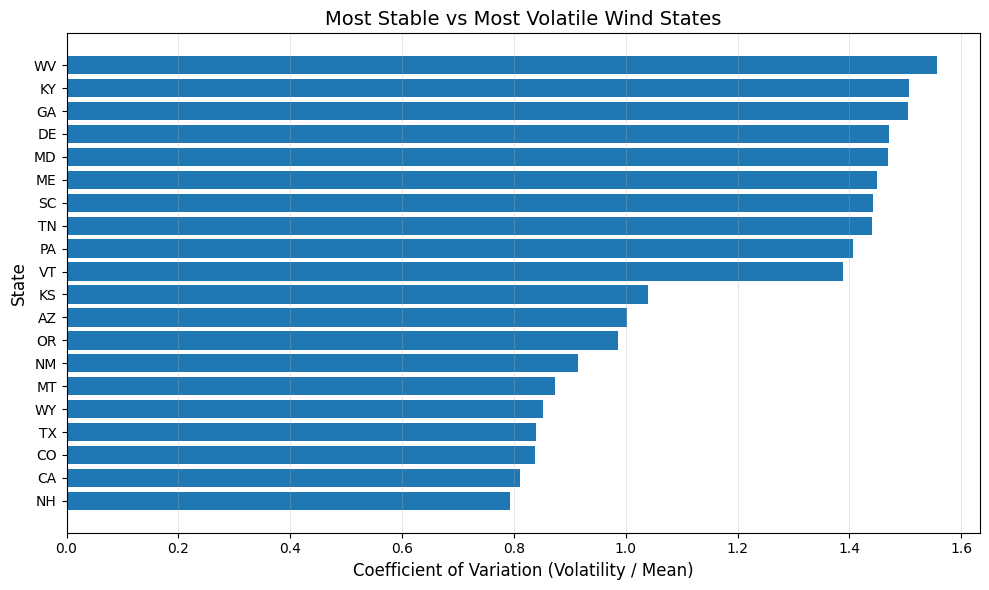

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort for clarity
cv_pd = stability_pd.sort_values("coefficient_of_variation")

# Take top + bottom for clarity (avoid clutter)
top_unstable = cv_pd.tail(10)
most_stable = cv_pd.head(10)

plot_df = pd.concat([most_stable, top_unstable])

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["state"],
    plot_df["coefficient_of_variation"]
)

plt.title("Most Stable vs Most Volatile Wind States", fontsize=14)
plt.xlabel("Coefficient of Variation (Volatility / Mean)", fontsize=12)
plt.ylabel("State", fontsize=12)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis

### 1. Relationship between wind strength and volatility

The scatter plot shows a clear upward trend:

- States with **higher wind potential also have higher volatility**
- Example:
  - North Dakota (ND) → high wind, high variability
  - Florida (FL) → low wind, low variability

→ Strong wind regions are **more powerful but less stable**

---

### 2. Stability ranking using coefficient of variation

The bar chart ranks states by relative variability:

- High CV → more unpredictable wind
- Low CV → more stable wind

### Key observations

- Some low-wind states (WV, KY, GA) have **very high variability relative to their mean**
- Some high-wind states (MT, WY) have **lower relative variability**
- California (CA) shows **moderate wind with relatively stable behavior**

---

### Insight

Wind stability is not just about absolute variability —  
it must be evaluated **relative to average wind levels**.

---

### Final interpretation

- High-wind states:
  - produce more energy  
  - but fluctuate more in absolute terms  

- Low-wind states:
  - produce less energy  
  - but can still be **highly unpredictable relative to their baseline**

---

### Answer to the question

**Q: Which regions have more stable wind patterns?**

→ Stability varies by region, but:

- Some **mid-to-high wind states offer the best balance** of strength and predictability  
- Extremely low-wind regions are **not necessarily stable** — they can be highly variable relative to their mean

# Q5: What are extreme wind events?

This analysis identifies **unusually low and unusually high wind days**.

We define extreme events using **state-level thresholds**:
- bottom 10% → low wind events
- top 10% → high wind events

This allows us to detect:
- rare high-energy opportunities
- periods of very low generation risk

In [14]:
from src.storage.table_builders import build_gold_extreme_event_windows

gold_extreme_events = build_gold_extreme_event_windows(region_daily)

gold_extreme_events.cache()

DataFrame[state: string, date_utc: date, year: int, month: int, season: string, daily_region_capacity_factor: double, mean_region_wind_speed_ms: double, station_count: bigint, total_hourly_observations: bigint, state_low_wind_threshold: double, state_high_wind_threshold: double, state_avg_capacity_factor: double, state_std_capacity_factor: double, capacity_factor_z_score: double, is_extreme_low_wind_day: boolean, is_extreme_high_wind_day: boolean, is_extreme_event_day: boolean, extreme_event_type: string]

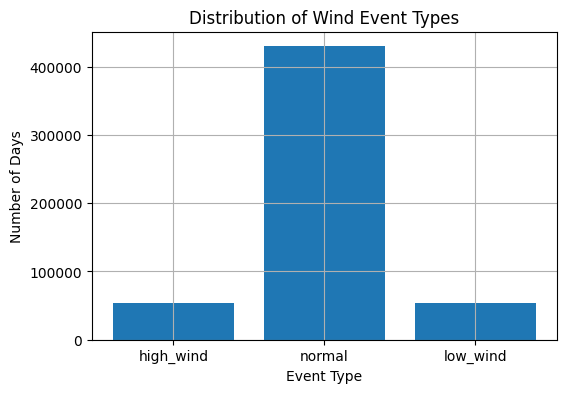

In [15]:
from pyspark.sql import functions as F

extreme_counts = (
    gold_extreme_events
    .groupBy("extreme_event_type")
    .count()
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(extreme_counts["extreme_event_type"], extreme_counts["count"])
plt.title("Distribution of Wind Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Days")
plt.grid(True)
plt.show()

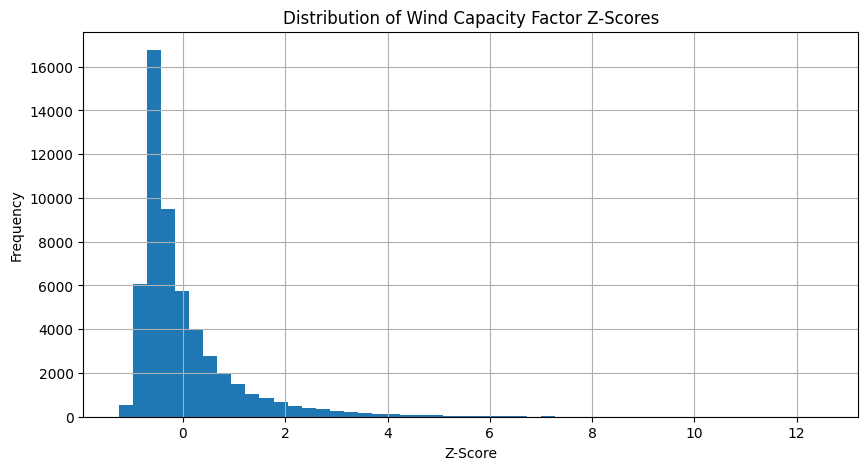

In [16]:
z_sample = (
    gold_extreme_events
    .select("capacity_factor_z_score")
    .where(F.col("capacity_factor_z_score").isNotNull())
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(z_sample["capacity_factor_z_score"], bins=50)
plt.title("Distribution of Wind Capacity Factor Z-Scores")
plt.xlabel("Z-Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Analysis — Extreme Wind Events and Stability

### What is a Z-score in this context?

The Z-score measures how **unusual a day's wind potential is relative to its state's normal behavior**.

It is calculated as:

Z = (daily capacity factor − state average) / state standard deviation

### Interpretation

- Z = 0 → normal day (average wind conditions)  
- Z > 0 → above-average wind  
- Z < 0 → below-average wind  

Magnitude tells how extreme:

- |Z| ≈ 1 → slightly unusual  
- |Z| ≈ 2 → rare event  
- |Z| > 3 → very extreme event  

---

### What the plot shows

- Most values are clustered around **Z ≈ 0**  
  → most days are close to normal  

- The distribution is **right-skewed**  
  → extremely high wind days are more pronounced than extremely low ones  

- Long tail up to very high Z values (~10+)  
  → rare but very strong wind events exist  

---

### Key insight

Z-score transforms raw wind values into **relative extremeness**,  
making it possible to compare across states with very different wind regimes.

---

### How are extreme wind events defined?

We do NOT use fixed thresholds (like wind speed > X).

Instead, we use **state-specific percentiles**:

- Bottom 10% → low wind days  
- Top 10% → high wind days  
- Middle 80% → normal days  

---

### Why this approach?

Different states have very different wind characteristics:

- North Dakota has naturally high wind  
- Florida has naturally low wind  

A fixed threshold would be misleading.

Instead, we define "extreme" **relative to each state's own distribution**, ensuring fair comparison across regions.

---

### What the bar chart shows

- ~80% of days are normal  
- ~10% are low wind  
- ~10% are high wind  

---

### Key insight

Extreme events are:

- **rare by definition**  
- **state-relative, not absolute**  
- critical for understanding:
  - energy shortages (low wind)
  - energy surges (high wind)

---

### Final Interpretation

Z-score and percentiles serve different roles:

- Z-score provides a **continuous measure of extremeness**
- Percentiles provide a **clear classification for decision-making**

---

### Key takeaway

Wind is not just about average levels —  
it is about how often and how severely it deviates from normal.

Understanding these deviations is critical for:
- forecasting
- grid stability
- energy planning

## Key Insights Summary

- Wind potential is **strongly location-dependent**  
  → Great Plains dominate, Southeast lags behind  

- Wind follows a clear **seasonal pattern**  
  → peaks in winter/spring, dips in summer  

- Wind is **generally stable but not constant**  
  → most days are moderate, with rare extreme spikes  

- Higher wind regions tend to have **higher variability**  
  → more energy, but less consistency  

- Extreme events are **rare but impactful**  
  → critical for grid stability and forecasting  

- Daily aggregation provides the best balance  
  → reduces noise while preserving meaningful patterns  

### Final takeaway

Wind is not random —  
it is **structured, predictable, and forecastable**.

Wind isn’t unreliable — it’s variable, and once you understand that variability, you can design systems around it.

### Analysis

The seasonal pattern shows a strong and consistent variation in wind energy potential throughout the year.

Wind potential increases from winter into spring, peaking in March and April at around 0.063. 
This means that, on average, turbines are producing about 6.3% of their maximum possible output during peak months.

After this peak, wind potential declines sharply through the summer, reaching a minimum of around 0.021 in August — roughly one-third of the peak value.

This is a **large seasonal swing (≈3x difference)**.

This pattern reflects atmospheric physics:
- winter and spring have stronger pressure gradients → stronger winds
- summer has more stable air → weaker winds

### Insight

Wind energy is **highly seasonal but predictable**.

### Real-world meaning

- Energy production from wind is not constant across the year
- Summer is a low-production period
- Grid systems must plan for seasonal drops
- Forecasting is feasible because this pattern is stable and repeatable